# 01 · מבוא ל-Information Fusion
**מבוסס על:** *Introduction to Data Fusion* — Erik Blasch, FUSION Boot Camp 2026.

### Take-aways של ההרצאה
1. **מהו Data Fusion?** — היתוך מקטין אי-ודאות; הכמת אי-הוודאות היא השׁוֹנוּת `P` (covariance).
2. **שיטות:** רישום נתונים (registration) = קורלציה; היתוך נתונים (fusion) = שיוך נתונים (association).
3. **מה fusion *יכול* ולא יכול לעשות:** מרחיב כיסוי במרחב/זמן ומקטין עומס נתונים; אינו 'מספר קסם', אינו מתקן נתונים גרועים, ואינו מחליף הסקה אנושית.
4. **ארכיטקטורות:** מודל JDL/DFIG, רמות 0–5 (טקסונומיה); חישה רב-תחומית (חלל, אוויר, סייבר) המשלבת hard (תמונות) ו-soft (טקסט).

## א. היסטוריה קצרה של רעיון ה-Fusion
Blasch ממקם את היתוך המידע ברצף היסטורי ארוך של 'איחוד חושים' והסקה:

| תקופה | תרומה |
|-------|-------|
| יוונים | אפלטון — טענות/אמונות/ראיות; אריסטו — הנשמה כמאחדת חושים |
| מטריאליזם | דקארט — גוף ונפש; אינטראקציה סיבתית (חומר ותנועה) |
| 1500–1700 | קפלר, גלילאו, ניוטון — תנועה ואינטראקציה דינמית |
| 1700 | Bayes — אמונות (probability) |
| 1800 | ניסויים — תגובה לגירוי |
| 1900 | Galton, Pearson — קורלציה (שיוך); William James — איחוד חושים (FUSE) |
| 1960 | **מסנן קלמן (Kalman Filter)** |
| 1990 | סדרת הספרים הראשונה על Sensor & Data Fusion |

### Fusion כמדע: שלושה שערים
* **אונטולוגיה (Ontology)** — מהו 'העולם' ומבניו (הצהרה על מה שקיים; למשל החישה).
* **אפיסטמולוגיה (Epistemology)** — כללי המשחק; כיצד יודעים משהו (כללי ה-fusion).
* **טקסונומיה (Taxonomy)** — סיווג/סמנטיקה של המידע.

## ב. סוגי היסק (Inference) ב-Fusion ברמה גבוהה

| | Inductive | Deductive | Abductive |
|---|-----------|-----------|-----------|
| פעולה | מהתבוננות להבנה כללית | גזירת תוצאה מתוך חוק | היסק ההסבר הסביר ביותר לתצפית |
| כיוון | מהפרטי לכללי | מהכללי לפרטי | שילוב יחסים |
| שיטות | Probability, Bayesian, entropy | If-then, Hypothesis tests | Bayes Nets |

*(E. Blasch, P. Valin, E. Bossé, "Measures of Effectiveness for High-Level Fusion," Fusion 2010.)*

## ג. משוואת ה-Fusion המרכזית (Key Fusion Equation)
הטענה המרכזית: **fusion מקטין אי-ודאות**. כאשר ממזגים שתי מדידות בלתי-תלויות של אותו ערך, 
עם שונויות $P_1, P_2$ (או $\sigma_1^2,\sigma_2^2$), מתקבל אומדן ממוזג ש**השונות שלו קטנה מכל אחת מהן**:

$$\frac{1}{P_F} = \frac{1}{P_1} + \frac{1}{P_2} \quad\Longrightarrow\quad P_F = \frac{P_1 P_2}{P_1 + P_2}$$

(adapted from Maybeck, 1978). זוהי בדיוק נוסחת מיזוג שני גאוסיאנים — שקולה לעדכון מדידה במסנן קלמן.

**דוגמת השקופית:** עם $\sigma_1^2=1$ ו-$\sigma_2^2=4$ מתקבל $P_F = \tfrac{1\cdot4}{1+4}=0.8$, כלומר $\sigma_F=\sqrt{0.8}\approx0.90$ — קטן מ-$\sigma_1=1$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def fuse(x1, P1, x2, P2):
    """מיזוג שני אומדנים גאוסיאניים בלתי-תלויים (סקלר או מטריצה).
    מחזיר את האומדן הממוזג ואת השונות הממוזגת."""
    P1, P2 = np.asarray(P1, float), np.asarray(P2, float)
    if P1.ndim == 0:  # סקלר
        PF = (P1 * P2) / (P1 + P2)
        xF = PF * (x1 / P1 + x2 / P2)
        return xF, PF
    PF = np.linalg.inv(np.linalg.inv(P1) + np.linalg.inv(P2))  # מיזוג ע"י מידע (information form)
    xF = PF @ (np.linalg.inv(P1) @ x1 + np.linalg.inv(P2) @ x2)
    return xF, PF

# דוגמת השקופית
xF, PF = fuse(0.0, 1.0, 0.0, 4.0)
print(f'P_F = {PF:.3f},  sigma_F = {np.sqrt(PF):.3f}  (קטן מ-sigma_1=1 ומ-sigma_2=2)')

P_F = 0.800,  sigma_F = 0.894  (קטן מ-sigma_1=1 ומ-sigma_2=2)


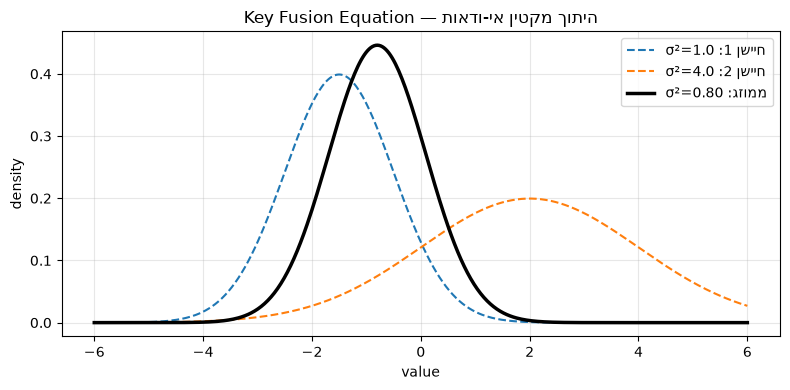

שים לב: שיא הצפיפות הממוזגת גבוה וצר יותר -> שונות קטנה יותר.


In [2]:
# ויזואליזציה: שני גאוסיאנים והגאוסיאן הממוזג
from math import sqrt, pi
x = np.linspace(-6, 6, 400)
def gauss(x, mu, var):
    return np.exp(-(x-mu)**2/(2*var))/sqrt(2*pi*var)

x1, P1, x2, P2 = -1.5, 1.0, 2.0, 4.0
xf, Pf = fuse(x1, P1, x2, P2)
plt.figure(figsize=(8,4))
plt.plot(x, gauss(x, x1, P1), '--', label=f'חיישן 1: σ²={P1}')
plt.plot(x, gauss(x, x2, P2), '--', label=f'חיישן 2: σ²={P2}')
plt.plot(x, gauss(x, xf, Pf), 'k', lw=2.5, label=f'ממוזג: σ²={Pf:.2f}')
plt.title('Key Fusion Equation — היתוך מקטין אי-ודאות')
plt.xlabel('value'); plt.ylabel('density'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()
print('שים לב: שיא הצפיפות הממוזגת גבוה וצר יותר -> שונות קטנה יותר.')

### הקטנת אליפסת השונות (Covariance Ellipse Reduction) — מקרה דו-ממדי
כאשר שני חיישנים מודדים מיקום במישור עם אליפסות שגיאה שונות (למשל רדאר מדויק בטווח ולא בזווית, 
וחיישן אופטי להפך), המיזוג מצמצם את שטח האליפסה — בדיוק העיקרון שמאחורי טריאנגולציה.

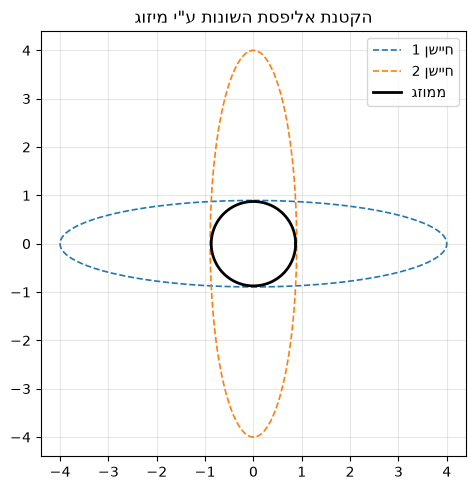

det(P1)=0.800 det(P2)=0.800 det(P_F)=0.036  (שטח האליפסה הממוזגת קטן בהרבה)


In [3]:
def cov_ellipse(P, mean=(0,0), n_std=2.0, **kw):
    vals, vecs = np.linalg.eigh(P)
    t = np.linspace(0, 2*np.pi, 200)
    circle = np.array([np.cos(t), np.sin(t)])
    ell = vecs @ np.diag(n_std*np.sqrt(vals)) @ circle
    return ell[0]+mean[0], ell[1]+mean[1]

P1 = np.array([[4.0, 0.0],[0.0, 0.2]])   # מדויק לאורך y, גס לאורך x
P2 = np.array([[0.2, 0.0],[0.0, 4.0]])   # להפך
xF, PF = fuse(np.zeros(2), P1, np.zeros(2), P2)

plt.figure(figsize=(5,5))
for P, lab, st in [(P1,'חיישן 1','C0--'),(P2,'חיישן 2','C1--'),(PF,'ממוזג','k-')]:
    ex, ey = cov_ellipse(P)
    plt.plot(ex, ey, st, lw=2 if lab=='ממוזג' else 1.2, label=lab)
plt.gca().set_aspect('equal'); plt.legend(); plt.grid(alpha=.3)
plt.title('הקטנת אליפסת השונות ע"י מיזוג'); plt.tight_layout(); plt.show()
print('det(P1)=%.3f det(P2)=%.3f det(P_F)=%.3f  (שטח האליפסה הממוזגת קטן בהרבה)'
      % (np.linalg.det(P1), np.linalg.det(P2), np.linalg.det(PF)))

## ד. מודל ה-JDL/DFIG — רמות ה-Fusion 0–5
הטקסונומיה הסטנדרטית לתיאור פונקציות ה-fusion (JDL במקור, הורחב ל-DFIG ב-2006):

| רמה | שם | תיאור |
|-----|-----|-------|
| **L0** | Sub-object / Signal | רישום ועיבוד אות, חילוץ מאפיינים |
| **L1** | Object assessment | גילוי, זיהוי (classification), ומעקב (tracking) של עצמים |
| **L2** | Situation assessment | אמידת יחסים בין ישויות; תמונת מצב |
| **L3** | Threat / Impact assessment | אמידת איום, כוונה (intent), והשלכות עתידיות |
| **L4** | Process refinement | ניהול חיישנים ובקרה (sensor management) |
| **L5** | User refinement | האדם בלולאה — הצגה, אינטראקציה, החלטה |

*("DFIG (Data Fusion Information Group), Situation Assessment", J. of Adv. in Info. Fusion, Dec. 2006.)*

**מה אפשר היום (Can Do):** רישום תמונה (L0), גילוי/זיהוי ומעקב מטרות לא-מתמרנות בסביבה דלילה (L1), 
הסקה אוטומטית מוגבלת ב-L2/L3, אופטימיזציה לחיישנים תואמים ב-L4, ואספקת אומדנים לאדם ב-L5.  
**מה עדיין קשה (Can NOT Do):** מעקב מדויק אחר מטרות מתמרנות בצפיפות גבוהה, התקרבות ליכולת ההסקה האנושית, 
מידול מדויק של כוונה, ואופטימיזציה של חיישנים לא-תואמים מבוזרים.

In [4]:
# היררכיית ההיסק (Inference Hierarchy) — מרמת אות לרמת ידע
levels = [
    ('L0 אות',        'Signal Processing',     'גילוי, מאפיינים'),
    ('L1 עצם',        'Estimation',            'Kalman/Bayesian, MAP'),
    ('L2 מצב',        'Decision-level',        'Bayesian nets, fuzzy, NN'),
    ('L3 איום',       'Knowledge-based',       'מערכות מומחה, CBR'),
    ('L4/L5 ניהול',   'Control / User',        'sensor mgmt, human-in-loop'),
]
print(f"{'רמה':<12}{'טכניקות':<22}{'דוגמאות'}")
print('-'*60)
for lv, tech, ex in levels:
    print(f'{lv:<12}{tech:<22}{ex}')

רמה         טכניקות               דוגמאות
------------------------------------------------------------
L0 אות      Signal Processing     גילוי, מאפיינים
L1 עצם      Estimation            Kalman/Bayesian, MAP
L2 מצב      Decision-level        Bayesian nets, fuzzy, NN
L3 איום     Knowledge-based       מערכות מומחה, CBR
L4/L5 ניהול Control / User        sensor mgmt, human-in-loop


## ה. יתרונות וחסרונות

**יתרונות (Waltz & Llinas, 1990):** ביצועים חסינים (redundancy), כיסוי מרחבי וזמני מורחב, 
ביטחון מוגבר והפחתת עמימות, שיפור גילוי ורזולוציה, הגדלת ממד מרחב המדידה (עמידות לשיבוש).  
בקצרה: *מרחיב כיסוי ספקטרלי/מרחבי/זמני ומקטין אי-ודאות ועמימות; מקטין יחס אות-לרעש.*

**חסרונות / מלכודות:** מיזוג נתונים תלויים (ספירה כפולה), מיזוג נתונים לא-עקביים, מיזוג נתון גרוע עם טוב, 
אומדן ממוזג חסר-משמעות, הסתמכות-יתר על 'המספר', ואי-הבנת ההנחות של האלגוריתם (רוב האלגוריתמים מניחים אי-תלות).

> **"סודות" ה-Data Fusion (D. Hall):** אין תחליף לחיישן טוב; עיבוד במורד הזרם אינו מתקן עיבוד גרוע במעלה הזרם; 
> התוצאה הממוזגת עלולה להיות גרועה מהחיישן הטוב ביותר; אין אלגוריתמי קסם; לעולם לא יהיו מספיק נתוני אימון.

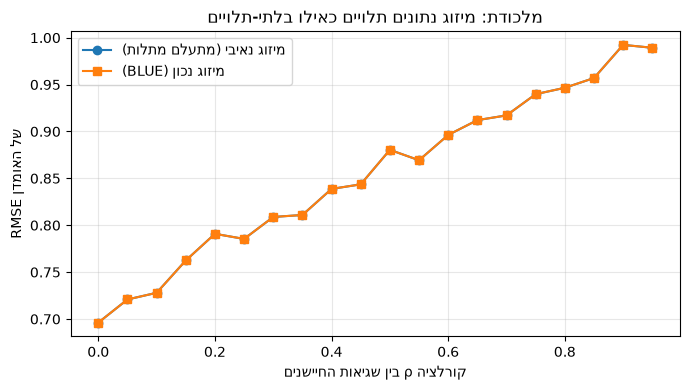

In [5]:
# הדגמה כמותית למלכודת: מיזוג שתי מדידות *תלויות* כאילו היו בלתי-תלויות
# נניח קורלציה rho בין שגיאות שני החיישנים. הנוסחה הנאיבית מתעלמת ממנה.
rng = np.random.default_rng(0)
rho_values = np.linspace(0, 0.95, 20)
true_x = 0.0
s1 = s2 = 1.0  # סטיות תקן
naive_rmse, correct_rmse = [], []
for rho in rho_values:
    cov = np.array([[s1**2, rho*s1*s2],[rho*s1*s2, s2**2]])
    L = np.linalg.cholesky(cov)
    errs_naive, errs_corr = [], []
    for _ in range(4000):
        e = L @ rng.standard_normal(2)
        z1, z2 = true_x + e
        # נאיבי: מתעלם מקורלציה -> ממוצע פשוט (מיזוג שונות שווה)
        x_naive = 0.5*z1 + 0.5*z2
        # נכון: BLUE עם מטריצת השונות המלאה
        ones = np.ones(2)
        w = np.linalg.solve(cov, ones); w /= ones @ w
        x_corr = w @ np.array([z1, z2])
        errs_naive.append((x_naive-true_x)**2)
        errs_corr.append((x_corr-true_x)**2)
    naive_rmse.append(np.sqrt(np.mean(errs_naive)))
    correct_rmse.append(np.sqrt(np.mean(errs_corr)))

plt.figure(figsize=(7,4))
plt.plot(rho_values, naive_rmse, 'o-', label='מיזוג נאיבי (מתעלם מתלות)')
plt.plot(rho_values, correct_rmse, 's-', label='מיזוג נכון (BLUE)')
plt.xlabel('קורלציה ρ בין שגיאות החיישנים'); plt.ylabel('RMSE של האומדן')
plt.title('מלכודת: מיזוג נתונים תלויים כאילו בלתי-תלויים')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## סיכום
* **Fusion = הקטנת אי-ודאות.** משוואת ה-Fusion ($1/P_F=1/P_1+1/P_2$) היא הליבה — שקולה לעדכון מדידה בקלמן.
* **מודל JDL/DFIG** נותן טקסונומיה (L0–L5) מאות ועד האדם בלולאה.
* היתוך **מרחיב** כיסוי ו**מקטין** אי-ודאות — אך **אינו** יוצר יש מאין, ותלוי קריטית בהנחת אי-התלות.

המחברות הבאות יורדות לטכניקה: **אמידה (estimation)** — ליבת רמה L1.